data wramgling steps:
1. gathering data
2. accessing the data(EDA)
3.  cleaning the data
    1. dealing the missing values
    2. correcting errors in the dataset
        1. outliers removel
            1. visualization 
            2. IQR method
            3. Z_score
    3. droping duplicates
4. transforming the data
   1. normalize the data (data normalization)
      1. min_max normalization
      2. winsorization
      3. Z-score normalization
      4. Decimal Scaling
      5. Log transformation

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
df= sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [185]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [186]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [188]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [189]:
df.isnull().sum() * 100 / len(df)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [190]:
df.drop(columns='deck', inplace=True)

In [191]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [192]:
df['age']= df.age.fillna(df['age'].mean())

In [193]:
df['embarked']= df.embarked.fillna(df['embarked'].mode()[0])

In [194]:
df['embark_town']= df.embark_town.fillna(df['embark_town'].mode()[0])

In [195]:
df.isnull().sum() *100/ len(df)

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64

In [196]:
import seaborn as sns

<Axes: ylabel='age'>

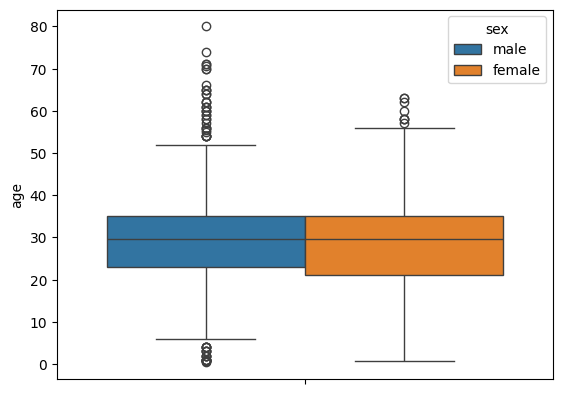

In [197]:
sns.boxplot(data=df, y='age', hue='sex')

In [198]:
# IQR method
Q1= df['age'].quantile(0.25)
Q3= df['age'].quantile(0.75)
IQR = Q3 - Q1
IQR
upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR
df=df[(df['age']> lower_bound) & (df['age']< upper_bound)]

In [199]:
df.shape

(825, 14)

In [200]:
Q1= df['fare'].quantile(0.25)
Q3= df['fare'].quantile(0.75)
IQR = Q3 - Q1
IQR
upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR
df=df[(df['fare']> lower_bound) & (df['fare']< upper_bound)]

In [201]:
df.shape

(718, 14)

<Axes: xlabel='age', ylabel='Count'>

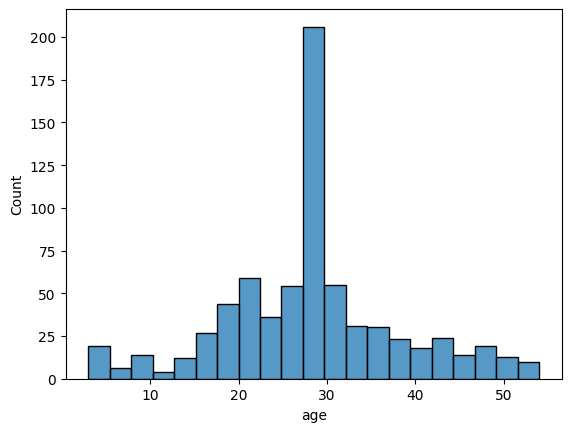

In [202]:
sns.histplot(data = df , x='age')

In [203]:
# zscore method 
# pip install scipy
from scipy import stats
import numpy as np
zscore = np.abs(stats.zscore(df['age']))
threshold = 3
df = df[(z < threshold). all(axis=1)]

NameError: name 'z' is not defined

In [114]:
# finding and dropping duplicates
# finding
df.duplicated().sum()


np.int64(101)

In [116]:
df.shape

(653, 14)

In [117]:
df.drop_duplicates(inplace=True)

In [118]:
df.shape

(552, 14)

In [ ]:
#pip install scikit-learn
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler

In [58]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [60]:
# which columns are to be normalized
cols_to_normalize = ['age', 'fare']
# create scaler function/tool
scaler = MinMaxScaler()
#fit and transform data on scaler and vise versacols_
df[cols_to_normalize]= scaler.fit_transform(df[cols_to_normalize])
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,0.372549,1,0,0.118118,S,Third,man,True,Southampton,no,False
2,1,3,female,0.450980,0,0,0.129115,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.627451,1,0,0.865114,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.627451,0,0,0.131152,S,Third,man,True,Southampton,no,True
5,0,3,male,0.523512,0,0,0.137804,Q,Third,man,True,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0.470588,0,0,0.211798,S,Second,man,True,Southampton,no,True
887,1,1,female,0.313725,0,0,0.488765,S,First,woman,False,Southampton,yes,True
888,0,3,female,0.523512,1,2,0.382051,S,Third,woman,False,Southampton,no,False
889,1,1,male,0.450980,0,0,0.488765,C,First,man,True,Cherbourg,yes,True


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,718.000000,718.000000,718.000000,718.000000,718.000000,718.000000
mean,0.334262,2.512535,0.499270,0.413649,0.317549,0.280114
std,0.472061,0.715818,0.196755,0.855001,0.784792,0.215782
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.372549,0.000000,0.000000,0.128538
50%,0.000000,3.000000,0.523512,0.000000,0.000000,0.191433
75%,1.000000,3.000000,0.585784,1.000000,0.000000,0.422426
max,1.000000,3.000000,1.000000,5.000000,6.000000,1.000000


In [205]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
cols_to_normalize = ['age', 'fare']
# create standard scaler function/tool
scaler = StandardScaler()
#fit and transform data on scaler and vise versacols_
df[cols_to_normalize]= scaler.fit_transform(df[cols_to_normalize])
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.644501,1,0,-0.751265,S,Third,man,True,Southampton,no,False
2,1,3,female,-0.245599,0,0,-0.700265,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.651930,1,0,2.712961,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.651930,0,0,-0.690821,S,Third,man,True,Southampton,no,True
5,0,3,male,0.123297,0,0,-0.659971,Q,Third,man,True,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,-0.145874,0,0,-0.316820,S,Second,man,True,Southampton,no,True
887,1,1,female,-0.943677,0,0,0.967626,S,First,woman,False,Southampton,yes,True
888,0,3,female,0.123297,1,2,0.472736,S,Third,woman,False,Southampton,no,False
889,1,1,male,-0.245599,0,0,0.967626,C,First,man,True,Cherbourg,yes,True


In [64]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,718.000000,718.000000,7.180000e+02,718.000000,718.000000,7.180000e+02
mean,0.334262,2.512535,-7.916911e-17,0.413649,0.317549,1.063835e-16
std,0.472061,0.715818,1.000697e+00,0.855001,0.784792,1.000697e+00
min,0.000000,1.000000,-2.539284e+00,0.000000,0.000000,-1.299043e+00
25%,0.000000,2.000000,-6.445008e-01,0.000000,0.000000,-7.029415e-01
50%,0.000000,3.000000,1.232969e-01,0.000000,0.000000,-4.112647e-01
75%,1.000000,3.000000,4.400131e-01,1.000000,0.000000,6.599744e-01
max,1.000000,3.000000,2.546712e+00,5.000000,6.000000,3.338501e+00


In [152]:
import numpy as np
import seaborn as snskashti
kashti = sns.load_dataset('titanic')
kashti.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:

kashti['age']= kashti.age.fillna(kashti['age'].median())
kashti['fare'] = kashti.fare.fillna(kashti['fare'].median())

In [154]:
kashti.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
import numpy as np
kashti['age'] = np.log(kashti['age'])
kashti['fare'] = np.log(kashti['fare'])
kashti.head()

c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,1.128508,1,0,0.683603,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,1.291320,1,0,1.450832,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,1.181143,0,0,0.727559,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,1.268453,1,0,1.379314,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,1.268453,0,0,0.735091,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='sex', ylabel='age'>

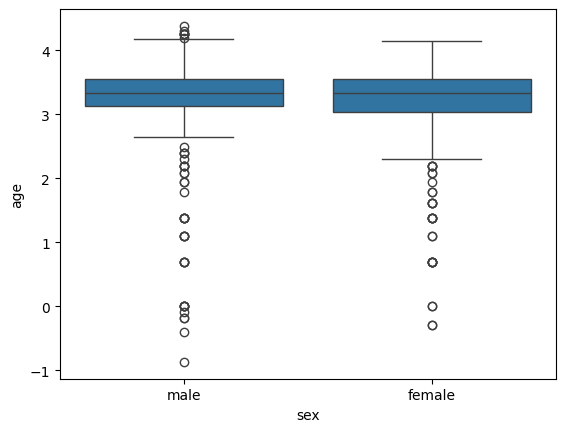

In [ ]:
sns.boxplot(data=kashti, x='sex', y='age')

<Axes: xlabel='age', ylabel='Count'>

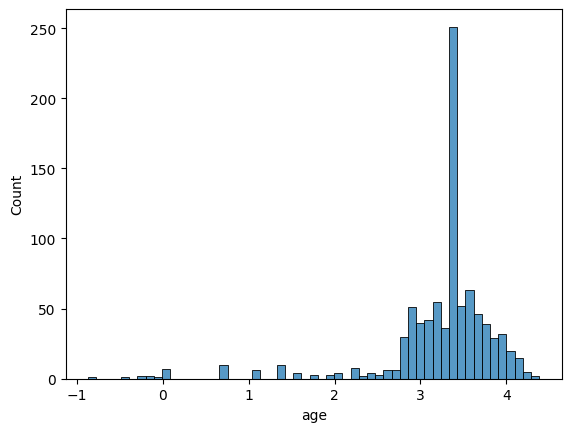

In [ ]:
sns.histplot(data= kashti, x='age')

<Axes: xlabel='sex', ylabel='fare'>

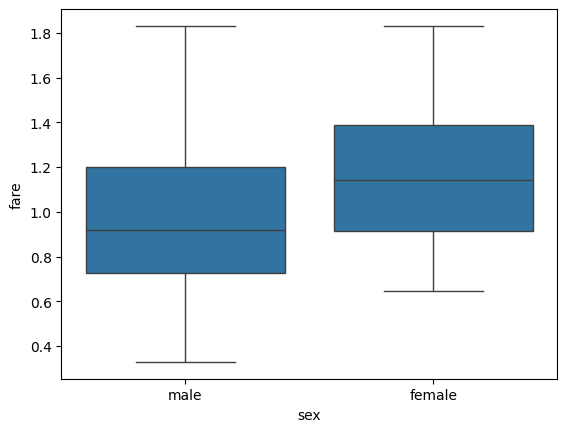

In [ ]:
sns.boxplot(data = kashti, x='sex', y='fare')

In [165]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [166]:
#organizing data
df['family_size']= df['sibsp']+ df['parch']

In [167]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'family_size'],
      dtype='object')

c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sex', ylabel='age'>

c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\AD\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


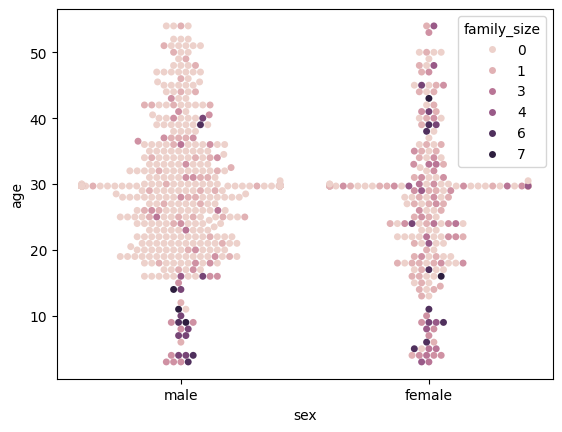

In [170]:
sns.swarmplot(data=df, x='sex', y='age', hue='family_size')

In [171]:
df= df.rename(columns={'survived':'survival'})

In [172]:
df.columns

Index(['survival', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'family_size'],
      dtype='object')

In [ ]:
table=pd.pivot_table(df, values='age', index='pclass',
    columns='survival', aggfunc=np.sum)
table

C:\Users\AD\AppData\Local\Temp\ipykernel_9880\2367953567.py:1: FutureWarning: The provided callable <function sum at 0x000002B594B7EF20> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table=pd.pivot_table(df, values='age', index='pclass',


survival,0,1
pclass,,
1,1500.287647,1835.592941
2,2741.893824,2071.296471
3,9592.416176,2694.770000


<Axes: xlabel='fare', ylabel='age'>

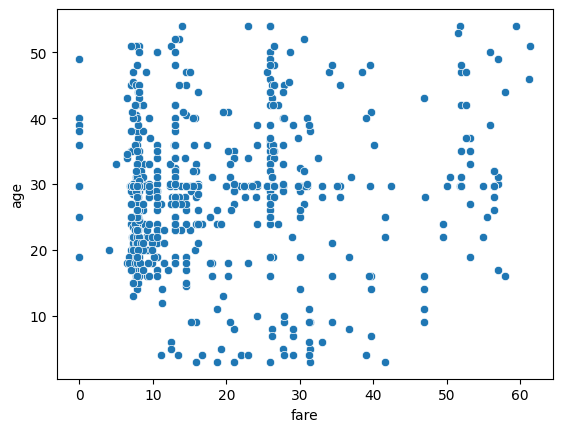

In [180]:
sns.scatterplot(data=df, x='fare', y='age')

In [206]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.644501,1,0,-0.751265,S,Third,man,True,Southampton,no,False
2,1,3,female,-0.245599,0,0,-0.700265,S,Third,woman,False,Southampton,yes,True
3,1,1,female,0.651930,1,0,2.712961,S,First,woman,False,Southampton,yes,False
4,0,3,male,0.651930,0,0,-0.690821,S,Third,man,True,Southampton,no,True
5,0,3,male,0.123297,0,0,-0.659971,Q,Third,man,True,Queenstown,no,True


In [207]:
df.to_csv("preprocessed_data.csv")